# Tarea 2 - Health Landscape – ENO + GRD
**Team members**: [Renato Fernández] , [Vicente Vargas]

**Region**: [Región Metropolitana de Santiago (Maipú)]

**Date**: [04/16/2026]

## Part A: ENO – Notifiable Diseases

### A.0 Data Loading & Cleaning

#### A.0.1 Load the ENO dataset

In [5]:
import pandas as pd

# Columnas necesarias
eno_cols = [
    "ENO",
    "anho_notificacion",
    "region",
    "codigo_comuna_residencia",
    "nacionalidad",
    "sexo",
    "grupo_edad",
    "nombre_instruccion",
    "cie_10_diagnostico",
    "diagnostico",
    "pais_contagio"
]

# Cargar dataset
eno = pd.read_csv(
    "20241218_base_eno_final.csv",
    sep=";",
    encoding="utf-8-sig",
    usecols=eno_cols
)

# Revisar dimensiones
print("Shape:", eno.shape)

# Revisar info
eno.info()

Shape: (333300, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333300 entries, 0 to 333299
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   region                    333300 non-null  object
 1   nacionalidad              333300 non-null  object
 2   cie_10_diagnostico        333300 non-null  object
 3   diagnostico               333300 non-null  object
 4   anho_notificacion         333300 non-null  int64 
 5   ENO                       333300 non-null  object
 6   nombre_instruccion        333300 non-null  object
 7   pais_contagio             333300 non-null  object
 8   sexo                      333300 non-null  object
 9   grupo_edad                333300 non-null  object
 10  codigo_comuna_residencia  333300 non-null  object
dtypes: int64(1), object(10)
memory usage: 28.0+ MB


#### A.0.2 Filter to your comunas

Definimos la comuna de de Maipú (13119) y filtramos la base ENO para conservar únicamente los registros correspondientes. Además, contabilizamos las filas cuyo codigo_comuna_residencia aparece anonimizado como "*****", ya que esos casos no pueden asignarse a una comuna específica y generan una subestimación en los conteos comunales.

In [8]:
# Definir comuna
MY_COMUNAS = [13119]

# Pasar comunas a texto
my_comunas_str = [str(c) for c in MY_COMUNAS]

# Filtrar filas de la comuna
eno_com = eno[eno["codigo_comuna_residencia"].isin(my_comunas_str)].copy()

# Contar filas anonimizadas
anon_rows = (eno["codigo_comuna_residencia"] == "*****").sum()

# Mostrar resultados
print(f"Rows in my comuna: {len(eno_com):,}")
print(f"Rows anonymized as '*****': {anon_rows:,}")

Rows in my comuna: 3,316
Rows anonymized as '*****': 148,217


Al filtrar la base ENO para Maipú se obtuvo el conjunto de casos con comuna identificable. Sin embargo, en la base total hay muchos registros donde la comuna aparece como “*****”, por lo que no es posible saber a qué comuna pertenecen. Por eso, los casos observados para Maipú no representan el total real, sino una cifra menor.

#### A.0.3 Clean the nationality variable

Analizamos la distribución de la variable nacionalidad, contabilizamos los casos clasificados como "Desconocido" y calculamos su proporción respecto del total. Luego, generamos una base limpia excluyendo estos registros para su uso en análisis posteriores.

In [12]:
# Ver distribución de nacionalidad
nat_dist = eno_com["nacionalidad"].value_counts(dropna=False)

print("Distribución nacionalidad:")
print(nat_dist)

# Contar desconocidos
unknown_count = (eno_com["nacionalidad"] == "Desconocido").sum()
total_rows = len(eno_com)

print(f"\nRows 'Desconocido': {unknown_count:,}")
print(f"Proportion: {unknown_count/total_rows:.2%}")

# Crear base limpia sin desconocidos
eno_clean = eno_com[eno_com["nacionalidad"] != "Desconocido"].copy()

print(f"\nRows after dropping 'Desconocido': {len(eno_clean):,}")

Distribución nacionalidad:
nacionalidad
Chile          1827
Desconocido    1222
Extranjero      267
Name: count, dtype: int64

Rows 'Desconocido': 1,222
Proportion: 36.85%

Rows after dropping 'Desconocido': 2,094


En la comuna de Maipú, la mayor parte de las notificaciones se concentra en personas clasificadas como chilenas, aunque también aparece una cantidad importante de casos con nacionalidad desconocida. Estos registros no se eliminan de forma general, pero sí se excluyen cuando el análisis requiere comparar chilenos y extranjeros, ya que no permiten asignar con claridad a uno de esos grupos. Por eso, para las secciones por nacionalidad se trabajará con una base limpia que deja fuera esos casos.

#### A.0.4 Report the time span

In [15]:
# Rango de años
year_min = eno_com["anho_notificacion"].min()
year_max = eno_com["anho_notificacion"].max()

print(f"Years range: {year_min} - {year_max}")

# Notificaciones por año
noti_year = (
    eno_com["anho_notificacion"]
    .value_counts()
    .sort_index()
    .reset_index()
)

noti_year.columns = ["año", "notificaciones"]

# Mostrar tabla
noti_year

Years range: 2007 - 2024


,año,notificaciones
0,2007,65
1,2008,106
2,2009,110
3,2010,91
4,2011,199
5,2012,155
6,2013,158
7,2014,152
8,2015,137
9,2016,156


In [16]:
print(f"\nTotal notificaciones: {noti_year['notificaciones'].sum():,}")


Total notificaciones: 3,316


Los datos de ENO para Maipú cubren el período 2007-2024, por lo que el análisis considera una ventana amplia de tiempo. Además, se observa que hay notificaciones en todos los años, aunque con diferencias importantes en la cantidad de casos reportados. Esto permite trabajar con una serie completa y da una primera idea de que la carga de notificaciones no se ha mantenido estable en el tiempo.

### A.1 Notification Trends Over Time

#### A.1.1 Overall trend

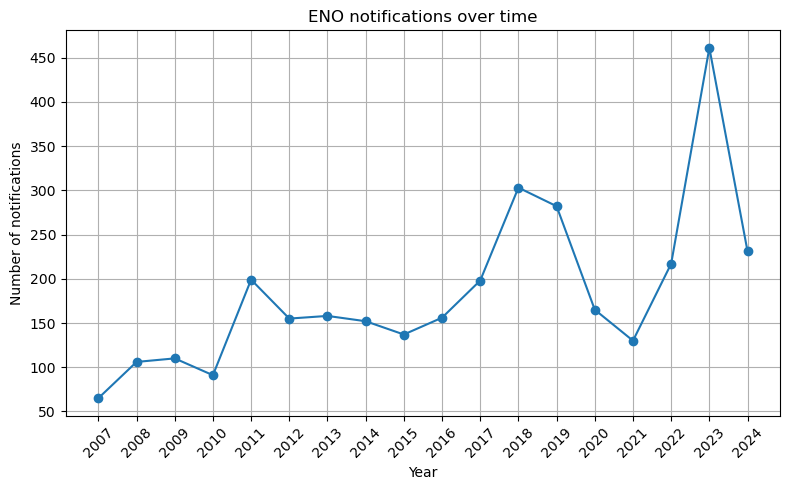

In [20]:
import matplotlib.pyplot as plt

# Notificaciones por año
trend = (
    eno_com["anho_notificacion"]
    .value_counts()
    .sort_index()
)

# Graficar tendencia
plt.figure(figsize=(8, 5))
plt.plot(trend.index, trend.values, marker="o")

plt.title("ENO notifications over time")
plt.xlabel("Year")
plt.ylabel("Number of notifications")

# Mostrar años exactos
plt.xticks(trend.index, rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()

La cantidad de notificaciones en Maipú no se mantiene estable a lo largo del tiempo, sino que muestra variaciones claras entre años. Se observan aumentos importantes en algunos períodos, especialmente hacia 2018 y luego en 2023, mientras que en 2020 y 2021 los casos bajan respecto de los años cercanos. En conjunto, el gráfico muestra que la carga de notificaciones ha cambiado bastante en el tiempo y que el período de pandemia probablemente influyó en esa dinámica.

#### A.1.2 Trend by nationality

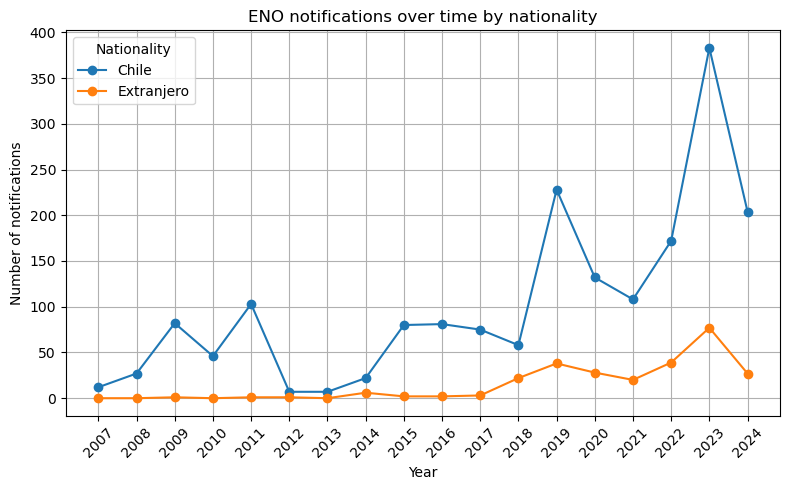

In [23]:
# Contar notificaciones por año y nacionalidad
trend_nat = (
    eno_clean
    .groupby(["anho_notificacion", "nacionalidad"])
    .size()
    .reset_index(name="n_notificaciones")
)

# Reordenar para graficar
trend_nat_wide = trend_nat.pivot(
    index="anho_notificacion",
    columns="nacionalidad",
    values="n_notificaciones"
).fillna(0)

# Graficar líneas
plt.figure(figsize=(8, 5))

for col in trend_nat_wide.columns:
    plt.plot(
        trend_nat_wide.index,
        trend_nat_wide[col],
        marker="o",
        label=col
    )

plt.title("ENO notifications over time by nationality")
plt.xlabel("Year")
plt.ylabel("Number of notifications")
plt.xticks(trend_nat_wide.index, rotation=45)
plt.legend(title="Nationality")
plt.grid(True)
plt.tight_layout()
plt.show()

Para poder realizar la comparación de forma más precisa, además de la visualización anterior, procederemos a mostrar la evolución de la proporción de notificaciones a tráves de los años entre chilenos y extranjeros.

In [25]:
# Calcular proporciones por año
trend_nat_share = trend_nat_wide.div(trend_nat_wide.sum(axis=1), axis=0) * 100

# Mostrar proporciones
trend_nat_share

nacionalidad,Chile,Extranjero
anho_notificacion,,
2007,100.000000,0.000000
2008,100.000000,0.000000
2009,98.795181,1.204819
2010,100.000000,0.000000
2011,99.038462,0.961538
2012,87.500000,12.500000
2013,100.000000,0.000000
2014,78.571429,21.428571
2015,97.560976,2.439024


Al mirar la evolución de las notificaciones por nacionalidad, se ve que en todos los años predominan los casos de personas chilenas. Sin embargo, al complementar el gráfico con la tabla de proporciones, también se nota que la presencia de personas extranjeras se vuelve más visible con el paso del tiempo, sobre todo en la parte más reciente de la serie. Aunque su participación no sigue una trayectoria totalmente estable, sí deja de ser marginal y pasa a tener un peso más relevante dentro del total de notificaciones.

### A.2 Disease Profiles

#### A.2.1 Top diseases overall

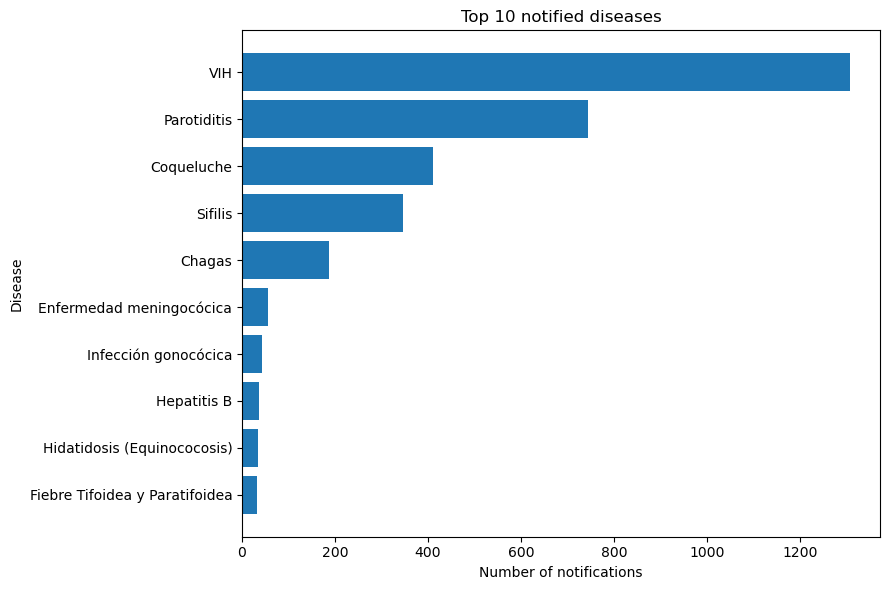

In [29]:
# Contar enfermedades
top_eno = (
    eno_com["ENO"]
    .value_counts()
    .head(10)
    .sort_values()
)

# Graficar barras horizontales
plt.figure(figsize=(9, 6))
plt.barh(top_eno.index, top_eno.values)

plt.title("Top 10 notified diseases")
plt.xlabel("Number of notifications")
plt.ylabel("Disease")
plt.tight_layout()
plt.show()

In [30]:
# Mostrar tabla
top_eno

ENO
Fiebre Tifoidea y Paratifoidea      32
Hidatidosis (Equinococosis)         35
Hepatitis B                         37
Infección gonocócica                42
Enfermedad meningocócica            55
Chagas                             186
Sifilis                            347
Coqueluche                         411
Parotiditis                        743
VIH                               1306
Name: count, dtype: int64

Al revisar las notificaciones totales, se ve que no todas las enfermedades tienen el mismo peso dentro de la comuna. VIH aparece como la más frecuente con bastante diferencia, seguida por parotiditis y coqueluche, mientras que otras como sífilis y Chagas también tienen una presencia relevante, pero menor. En conjunto, esto muestra que la carga de notificaciones en Maipú se concentra en un grupo acotado de enfermedades, más que en una distribución pareja entre todos los diagnósticos.

#### A.2.2 Disease profiles by nationality

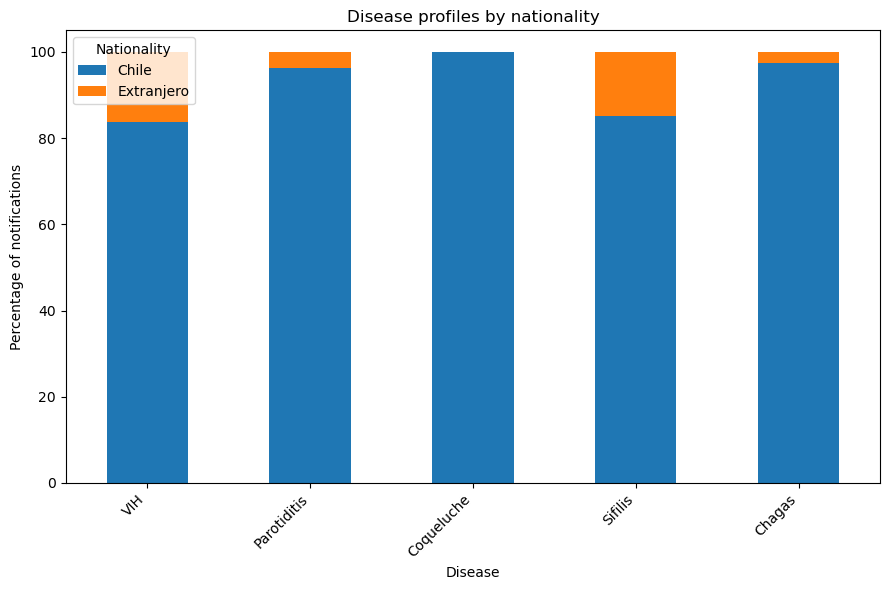

In [33]:
# Obtener top 5 enfermedades
top5_eno = (
    eno_com["ENO"]
    .value_counts()
    .head(5)
    .index
)

# Filtrar top 5 y excluir desconocido
eno_top5_nat = eno_clean[
    eno_clean["ENO"].isin(top5_eno)
].copy()

# Contar por enfermedad y nacionalidad
profile_nat = (
    eno_top5_nat
    .groupby(["ENO", "nacionalidad"])
    .size()
    .reset_index(name="n_notificaciones")
)

# Pasar a formato ancho
profile_nat_wide = profile_nat.pivot(
    index="ENO",
    columns="nacionalidad",
    values="n_notificaciones"
).fillna(0)

# Calcular proporciones
profile_nat_share = profile_nat_wide.div(
    profile_nat_wide.sum(axis=1),
    axis=0
) * 100

# Ordenar según frecuencia total
profile_nat_share = profile_nat_share.loc[top5_eno]

# Graficar barras apiladas
profile_nat_share.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6)
)

plt.title("Disease profiles by nationality")
plt.xlabel("Disease")
plt.ylabel("Percentage of notifications")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Nationality")
plt.tight_layout()
plt.show()

In [34]:
# Mostrar proporciones
profile_nat_share.round(2)

nacionalidad,Chile,Extranjero
ENO,,
VIH,83.67,16.33
Parotiditis,96.37,3.63
Coqueluche,100.00,0.00
Sifilis,85.01,14.99
Chagas,97.31,2.69


In [35]:
# Cargar resumen de Tarea 1
summary_t1 = pd.read_csv("Comuna_Level_Summary_Table.csv", encoding="latin-1")

# Ver porcentaje extranjero
summary_t1[["nombre_comuna", "pct_foreign"]]

,nombre_comuna,pct_foreign
0,maipú,6.19


Lo más relevante aquí es comparar cuánto pesa la población extranjera dentro de cada enfermedad. En VIH y sífilis, la proporción de extranjeros es bastante mayor al 6,19% que representan en la población de Maipú, por lo que en esos casos sí se observa una sobrerrepresentación relativa. En las demás enfermedades, su participación es más baja y se acerca menos a ese patrón.

#### A.2.3 Age-group distribution for the top disease

Top disease: VIH


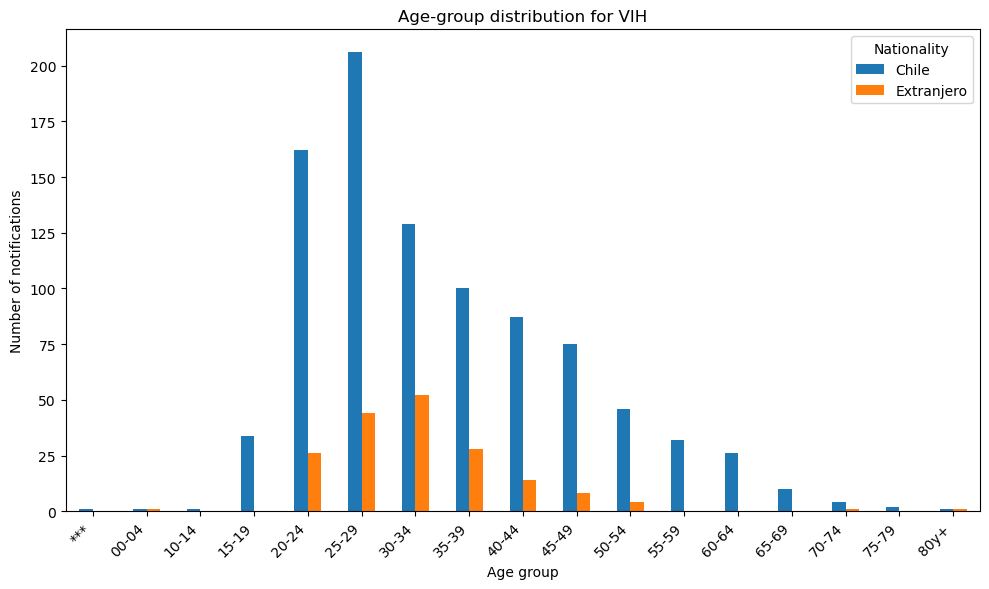

In [38]:
# Obtener enfermedad más frecuente
top_disease = eno_com["ENO"].value_counts().idxmax()

print(f"Top disease: {top_disease}")

# Filtrar enfermedad y excluir nacionalidad desconocida
eno_top_disease = eno_clean[
    eno_clean["ENO"] == top_disease
].copy()

# Contar por grupo de edad y nacionalidad
age_profile = (
    eno_top_disease
    .groupby(["grupo_edad", "nacionalidad"])
    .size()
    .reset_index(name="n_notificaciones")
)

# Pasar a formato ancho
age_profile_wide = age_profile.pivot(
    index="grupo_edad",
    columns="nacionalidad",
    values="n_notificaciones"
).fillna(0)

# Graficar barras agrupadas
age_profile_wide.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(f"Age-group distribution for {top_disease}")
plt.xlabel("Age group")
plt.ylabel("Number of notifications")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Nationality")
plt.tight_layout()
plt.show()

In [39]:
# Mostrar tabla
age_profile_wide

nacionalidad,Chile,Extranjero
grupo_edad,,
***,1.0,0.0
00-04,1.0,1.0
10-14,1.0,0.0
15-19,34.0,0.0
20-24,162.0,26.0
25-29,206.0,44.0
30-34,129.0,52.0
35-39,100.0,28.0
40-44,87.0,14.0


En el caso del VIH, la mayor parte de las notificaciones se concentra entre los 20 y 39 años tanto en población chilena como extranjera. Aun así, en personas extranjeras la distribución parece concentrarse más en los tramos de 25 a 34 años, mientras que en personas chilenas se reparte de forma un poco más amplia en edades cercanas. Fuera de esos grupos, la cantidad de registros baja de manera clara en ambos casos.

### A.3 Spatial View

#### A.3.1 Notification counts by comuna

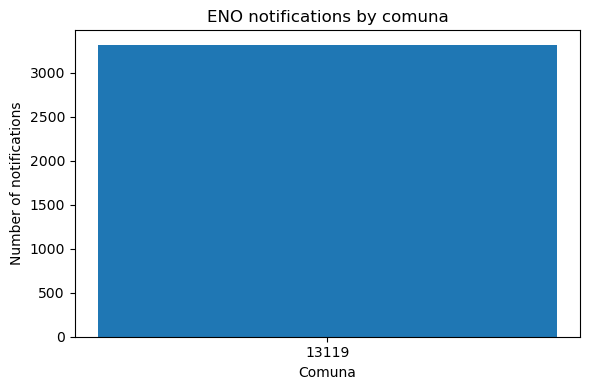

In [43]:
# Contar notificaciones por comuna
notif_comuna = (
    eno_com
    .groupby("codigo_comuna_residencia")
    .size()
    .reset_index(name="n_notificaciones")
)

# Graficar
plt.figure(figsize=(6,4))
plt.bar(
    notif_comuna["codigo_comuna_residencia"],
    notif_comuna["n_notificaciones"]
)

plt.title("ENO notifications by comuna")
plt.xlabel("Comuna")
plt.ylabel("Number of notifications")
plt.tight_layout()
plt.show()

Calculamos la tasa de notificaciones por cada 10.000 habitantes utilizando la población de la Tarea 1.

In [45]:
# Obtener población de Maipú
pop_total = summary_t1["pop_total"].iloc[0]

# Calcular tasa
notif_total = notif_comuna["n_notificaciones"].iloc[0]

rate = notif_total / pop_total * 10000

print(f"Notification rate per 10,000 inhabitants: {rate:.2f}")

Notification rate per 10,000 inhabitants: 66.24


In [46]:
# Obtener población y notificaciones
pop_total = summary_t1["pop_total"].iloc[0]
notif_total = notif_comuna["n_notificaciones"].iloc[0]

# Calcular tasa
rate = notif_total / pop_total * 10000

# Crear tabla
rate_table = pd.DataFrame({
    "codigo_comuna": [13119],
    "nombre_comuna": ["Maipú"],
    "notifications": [notif_total],
    "population": [pop_total],
    "rate_per_10k": [rate]
})

# Mostrar tabla
rate_table

,codigo_comuna,nombre_comuna,notifications,population,rate_per_10k
0,13119,Maipú,3316,500600,66.240511


Las notificaciones están subestimadas debido a la presencia de comunas anonimizadas ("*****"), por lo que los conteos por comuna no reflejan el total real de casos.

En este caso, como el análisis considera solo la comuna de Maipú, el gráfico funciona más como una forma simple de mostrar el total de notificaciones que como una herramienta de comparación. Para esta comuna se registran 3.316 notificaciones, lo que equivale a una tasa de 66,24 casos por cada 10.000 habitantes. Este valor permite interpretar mejor la magnitud del fenómeno en relación con el tamaño de la población. De todos modos, esta cifra debe leerse con cautela, ya que la existencia de registros con comuna anonimizada implica una subestimación del total real.

### A.4 Comuna-Level ENO Summary Table

In [50]:
import numpy as np
import os

# Cargar tabla resumen de Tarea 1
summary_t1 = pd.read_csv("Comuna_Level_Summary_Table.csv", encoding="latin-1")

# Asegurar mismo tipo de dato
summary_t1["codigo_comuna"] = summary_t1["codigo_comuna"].astype(str)

# Crear diccionarios de apoyo
comuna_name_map = dict(zip(summary_t1["codigo_comuna"], summary_t1["nombre_comuna"]))
pop_total_map = dict(zip(summary_t1["codigo_comuna"], summary_t1["pop_total"]))

# Crear función resumen
def build_eno_summary(g):
    codigo = g["codigo_comuna_residencia"].iloc[0]
    nombre = comuna_name_map.get(codigo, np.nan)
    pop_total = pop_total_map.get(codigo, np.nan)

    eno_total = len(g)
    eno_chilean = (g["nacionalidad"] == "Chile").sum()
    eno_foreign = (g["nacionalidad"] == "Extranjero").sum()
    eno_desconocido = (g["nacionalidad"] == "Desconocido").sum()

    top3 = (
        g["ENO"]
        .value_counts()
        .head(3)
        .index
        .tolist()
    )
    eno_top3_diseases = ", ".join(top3)

    eno_rate_per_10k = np.nan
    if pd.notna(pop_total) and pop_total > 0:
        eno_rate_per_10k = eno_total / pop_total * 10000

    return pd.Series({
        "codigo_comuna": codigo,
        "nombre_comuna": nombre,
        "eno_total": eno_total,
        "eno_chilean": eno_chilean,
        "eno_foreign": eno_foreign,
        "eno_desconocido": eno_desconocido,
        "eno_top3_diseases": eno_top3_diseases,
        "eno_rate_per_10k": eno_rate_per_10k
    })

# Construir tabla resumen
eno_summary = (
    eno_com.groupby("codigo_comuna_residencia")
    .apply(build_eno_summary)
    .reset_index(drop=True)
)

# Redondear tasa
eno_summary["eno_rate_per_10k"] = eno_summary["eno_rate_per_10k"].round(2)

# Definir descripciones
descriptions_eno = {
    "codigo_comuna": "Numeric comuna code",
    "nombre_comuna": "Comuna name (from your Tarea 1 data)",
    "eno_total": "Total ENO notifications (all years)",
    "eno_chilean": 'Notifications where nacionalidad == "Chile"',
    "eno_foreign": 'Notifications where nacionalidad == "Extranjero"',
    "eno_desconocido": 'Notifications where nacionalidad == "Desconocido"',
    "eno_top3_diseases": "Names of the top 3 diseases (comma-separated)",
    "eno_rate_per_10k": "Crude notification rate per 10,000 population"
}

# Crear tabla vertical
eno_summary_display = eno_summary.iloc[0].reset_index()
eno_summary_display.columns = ["Column", "Results"]

# Agregar descripciones
eno_summary_display["Description"] = eno_summary_display["Column"].map(descriptions_eno)

# Reordenar columnas
eno_summary_display = eno_summary_display[["Column", "Description", "Results"]]

# Mostrar tabla
eno_summary_display

,Column,Description,Results
0,codigo_comuna,Numeric comuna code,13119
1,nombre_comuna,Comuna name (from your Tarea 1 data),maipú
2,eno_total,Total ENO notifications (all years),3316
3,eno_chilean,"Notifications where nacionalidad == ""Chile""",1827
4,eno_foreign,"Notifications where nacionalidad == ""Extranjero""",267
5,eno_desconocido,"Notifications where nacionalidad == ""Desconocido""",1222
6,eno_top3_diseases,Names of the top 3 diseases (comma-separated),"VIH, Parotiditis, Coqueluche"
7,eno_rate_per_10k,"Crude notification rate per 10,000 population",66.24


## Part B: GRD – Hospital Discharges

### B.0 Data Loading & Cleaning

#### B.0.1 Load GRD files for 2022–2024

Cargamos los archivos GRD de 2022, 2023 y 2024 desde sus archivos ZIP. Como los archivos no comparten la misma codificación, usamos utf-16 para 2022 y 2023, y latin-1 para 2024. Luego, seleccionamos solo las columnas necesarias y unimos los tres años en una sola base, identificando automáticamente el archivo .txt contenido en cada uno.

In [55]:
import zipfile

# Definir columnas necesarias
grd_cols = [
    "COMUNA",
    "NACIONALIDAD",
    "SEXO",
    "FECHA_NACIMIENTO",
    "FECHA_INGRESO",
    "FECHAALTA",
    "TIPOALTA",
    "DIAGNOSTICO1",
    "DIAGNOSTICO2",
    "IR_29301_SEVERIDAD",
    "IR_29301_MORTALIDAD",
    "IR_29301_COD_GRD",
    "TIPO_INGRESO",
    "ESPECIALIDAD_MEDICA"
]

# Definir codificación por año
encoding_map = {
    2022: "utf-16",
    2023: "utf-16",
    2024: "latin-1"
}

# Crear lista de dataframes
frames = []

# Leer archivos por año
for year in [2022, 2023, 2024]:
    zippath = f"GRD_PUBLICO_{year}.zip"

    with zipfile.ZipFile(zippath) as z:
        txt_files = [name for name in z.namelist() if name.lower().endswith(".txt")]
        txtname = txt_files[0]

        with z.open(txtname) as f:
            df_year = pd.read_csv(
                f,
                sep="|",
                usecols=grd_cols,
                encoding=encoding_map[year],
                low_memory=False
            )

    # Agregar año
    df_year["year"] = year
    frames.append(df_year)

# Unir años
grd = pd.concat(frames, ignore_index=True)

# Revisar resultado
print(f"Total discharges (3 years): {len(grd):,}")
print("Shape:", grd.shape)
grd.info()

Total discharges (3 years): 3,058,240
Shape: (3058240, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3058240 entries, 0 to 3058239
Data columns (total 15 columns):
 #   Column               Dtype 
---  ------               ----- 
 0   SEXO                 object
 1   FECHA_NACIMIENTO     object
 2   COMUNA               object
 3   NACIONALIDAD         object
 4   TIPO_INGRESO         object
 5   ESPECIALIDAD_MEDICA  object
 6   FECHA_INGRESO        object
 7   FECHAALTA            object
 8   TIPOALTA             object
 9   DIAGNOSTICO1         object
 10  DIAGNOSTICO2         object
 11  IR_29301_COD_GRD     object
 12  IR_29301_SEVERIDAD   object
 13  IR_29301_MORTALIDAD  object
 14  year                 int64 
dtypes: int64(1), object(14)
memory usage: 350.0+ MB


In [56]:
grd.head()

,SEXO,FECHA_NACIMIENTO,COMUNA,NACIONALIDAD,TIPO_INGRESO,ESPECIALIDAD_MEDICA,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,DIAGNOSTICO2,IR_29301_COD_GRD,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,year
0,HOMBRE,2022-01-02,SAN FERNANDO,CHILE,URGENCIA,PEDIATRÍA,2022-08-01,2022-08-09,DOMICILIO,Q03.9,H55,011113,3,1,2022
1,MUJER,1981-07-05,COPIAPO,CHILE,PROGRAMADA,CARDIOLOGÍA,2022-11-01,2022-11-04,DOMICILIO,I47.1,I10,051401,1,1,2022
2,MUJER,1941-06-30,MELIPILLA,CHILE,URGENCIA,MEDICINA INTENSIVA ADULTO,2022-06-30,2022-07-06,FALLECIDO,S72.00,W19.09,084103,3,3,2022
3,MUJER,1997-01-26,MELIPILLA,CHILE,OBSTETRICA,OBSTETRICIA Y GINECOLOGÍA,2022-07-04,2022-07-07,DOMICILIO,O80.0,Z37.0,146131,1,1,2022
4,MUJER,1950-06-03,MELIPILLA,CHILE,URGENCIA,MEDICINA INTENSIVA ADULTO,2022-06-01,2022-07-04,DOMICILIO,J40,B96.2,044213,3,2,2022


In [57]:
print(grd.columns.tolist())

['SEXO', 'FECHA_NACIMIENTO', 'COMUNA', 'NACIONALIDAD', 'TIPO_INGRESO', 'ESPECIALIDAD_MEDICA', 'FECHA_INGRESO', 'FECHAALTA', 'TIPOALTA', 'DIAGNOSTICO1', 'DIAGNOSTICO2', 'IR_29301_COD_GRD', 'IR_29301_SEVERIDAD', 'IR_29301_MORTALIDAD', 'year']


#### B.0.2 Filter to your comunas

In [59]:
# Definir comuna en mayúsculas
my_comuna_names = ["MAIPU"]

# Filtrar comuna
grd_com = grd[grd["COMUNA"].isin(my_comuna_names)].copy()

# Mostrar total de egresos
print(f"Discharges in my comuna: {len(grd_com):,}")

# Contar egresos por año
grd_year = (
    grd_com["year"]
    .value_counts()
    .sort_index()
    .reset_index()
)

grd_year.columns = ["year", "n_discharges"]

# Mostrar tabla
grd_year

Discharges in my comuna: 62,614


,year,n_discharges
0,2022,19694
1,2023,21427
2,2024,21493


Al filtrar la base GRD para la comuna de Maipú se obtuvieron 62.614 egresos hospitalarios en total para el período 2022-2024. Al desagregar por año, se observa que los registros se mantienen en niveles relativamente similares, con 19.694 casos en 2022, 21.427 en 2023 y 21.493 en 2024. Esto muestra que la comuna concentra un volumen alto de egresos y que, dentro de este período, no se aprecia una caída marcada en la cantidad de hospitalizaciones registradas.

#### B.0.3 Compute length of stay

Verificamos la cobertura temporal antes del cálculo de estadía hospitalaria y convertimos las fechas usando varios formatos posibles, para evitar pérdidas de registros por errores de parsing. Luego, calculamos los días de estadía, filtramos los casos válidos y comprobamos nuevamente la distribución por año.

In [63]:
# Reconstruir base de Maipú
grd_com = grd[grd["COMUNA"] == "MAIPU"].copy()

# Revisar años antes de calcular los
year_check_before_los = (
    grd_com["year"]
    .value_counts()
    .sort_index()
    .reset_index()
)
year_check_before_los.columns = ["year", "n_discharges"]

print("Rows before los:", len(grd_com))
print(year_check_before_los)

# Crear función para probar varios formatos
def parse_mixed_date(series):
    s = series.astype(str).str.strip()
    parsed = pd.to_datetime(s, format="%d-%m-%Y", errors="coerce")
    parsed = parsed.fillna(pd.to_datetime(s, format="%Y-%m-%d", errors="coerce"))
    parsed = parsed.fillna(pd.to_datetime(s, format="%d/%m/%Y", errors="coerce"))
    parsed = parsed.fillna(pd.to_datetime(s, format="%Y/%m/%d", errors="coerce"))
    return parsed

# Convertir fechas
grd_com["fecha_ingreso_dt"] = parse_mixed_date(grd_com["FECHA_INGRESO"])
grd_com["fecha_alta_dt"] = parse_mixed_date(grd_com["FECHAALTA"])

# Revisar nulos por año
check_dates = (
    grd_com
    .groupby("year")
    .agg(
        n_rows=("year", "size"),
        pct_na_ingreso=("fecha_ingreso_dt", lambda x: x.isna().mean()),
        pct_na_alta=("fecha_alta_dt", lambda x: x.isna().mean())
    )
    .reset_index()
)

print("\nDate parsing check:")
print(check_dates)

# Calcular días de estadía
grd_com["los"] = (grd_com["fecha_alta_dt"] - grd_com["fecha_ingreso_dt"]).dt.days

# Contar casos inválidos
n_na_los = grd_com["los"].isna().sum()
n_negative_los = (grd_com["los"] < 0).sum()

# Filtrar casos válidos
grd_com = grd_com[(grd_com["los"].notna()) & (grd_com["los"] >= 0)].copy()

# Revisar años después de calcular los
year_check_after_los = (
    grd_com["year"]
    .value_counts()
    .sort_index()
    .reset_index()
)
year_check_after_los.columns = ["year", "n_discharges"]

print("\nRows after los:", len(grd_com))
print(year_check_after_los)

# Resumir distribución
los_summary = pd.DataFrame({
    "statistic": ["mean", "median", "min", "max"],
    "value": [
        grd_com["los"].mean(),
        grd_com["los"].median(),
        grd_com["los"].min(),
        grd_com["los"].max()
    ]
})

print(f"\nRows removed with los = NaN: {n_na_los:,}")
print(f"Rows removed with los < 0: {n_negative_los:,}")

los_summary["value"] = los_summary["value"].round(2)
los_summary

Rows before los: 62614
   year  n_discharges
0  2022         19694
1  2023         21427
2  2024         21493

Date parsing check:
   year  n_rows  pct_na_ingreso  pct_na_alta
0  2022   19694             0.0          0.0
1  2023   21427             0.0          0.0
2  2024   21493             0.0          0.0

Rows after los: 62614
   year  n_discharges
0  2022         19694
1  2023         21427
2  2024         21493

Rows removed with los = NaN: 0
Rows removed with los < 0: 0


,statistic,value
0,mean,7.02
1,median,3.00
2,min,0.00
3,max,541.00


La estadía hospitalaria en Maipú muestra bastante variación. En promedio fue de 7,02 días, pero la mediana fue de solo 3, lo que indica que muchos egresos se concentran en estadías cortas y que unos pocos casos más largos empujan el promedio hacia arriba. Además, no se encontraron registros con estadía negativa, por lo que no fue necesario eliminar observaciones por ese motivo.

#### B.0.4 Create a nationality grouping

In [66]:
# Crear grupo de nacionalidad
grd_com["nat_group"] = grd_com["NACIONALIDAD"].apply(
    lambda x: "Chilean" if x == "CHILE" else "Foreign"
)

# Contar distribución
nat_group_dist = grd_com["nat_group"].value_counts().reset_index()
nat_group_dist.columns = ["nat_group", "n_discharges"]

# Mostrar tabla
nat_group_dist

,nat_group,n_discharges
0,Chilean,58932
1,Foreign,3682


In [67]:
# Calcular proporción
nat_group_dist["proportion"] = (
    nat_group_dist["n_discharges"] / nat_group_dist["n_discharges"].sum()
).round(4)

nat_group_dist

,nat_group,n_discharges,proportion
0,Chilean,58932,0.9412
1,Foreign,3682,0.0588


Al agrupar la nacionalidad en chilenos y extranjeros, se ve que la gran mayoría de los egresos hospitalarios registrados en Maipú corresponde a personas chilenas. La población extranjera tiene una presencia bastante menor dentro del total, por lo que desde el inicio se observa una distribución poco equilibrada entre ambos grupos.

#### B.0.5 Join diagnoses to CIE-10

Cargamos la tabla CIE-10 y corregimos los nombres de sus columnas para respetar las tildes originales, ya que el archivo utiliza etiquetas como Código, Descripción y Capítulo. Luego, unimos esta tabla con DIAGNOSTICO1 para incorporar la descripción del diagnóstico y su capítulo, y finalmente contabilizamos cuántos registros no lograron hacer match con la tabla de referencia.

In [71]:
# Cargar tabla CIE-10
cie10 = pd.read_excel(
    "CIE-10.xlsx",
    sheet_name="CIE 10"
)

# Limpiar nombres de columnas
cie10.columns = cie10.columns.str.strip()

# Preparar llaves para el join
grd_com["DIAGNOSTICO1"] = grd_com["DIAGNOSTICO1"].astype(str).str.strip().str.upper()
cie10["Código"] = cie10["Código"].astype(str).str.strip().str.upper()

# Unir diagnósticos con CIE-10
grd_com = grd_com.merge(
    cie10[["Código", "Descripción", "Capítulo"]].drop_duplicates("Código"),
    left_on="DIAGNOSTICO1",
    right_on="Código",
    how="left"
)

# Contar filas sin match
n_unmatched = grd_com["Capítulo"].isna().sum()

# Mostrar resultado
print(f"Rows without CIE-10 match: {n_unmatched:,}")

Rows without CIE-10 match: 4


In [72]:
# Revisar diagnósticos sin match
grd_com.loc[grd_com["Capítulo"].isna(), "DIAGNOSTICO1"].value_counts()

DIAGNOSTICO1
DESCONOCIDO    4
Name: count, dtype: int64

Observamos que los pocos casos sin match corresponden a diagnósticos registrados como “DESCONOCIDO”, por lo que no reflejan un error en el proceso de unión con CIE-10, sino una limitación propia de los datos.

### B.1 Diagnostic Profile

#### B.1.1 Top diagnostic chapters

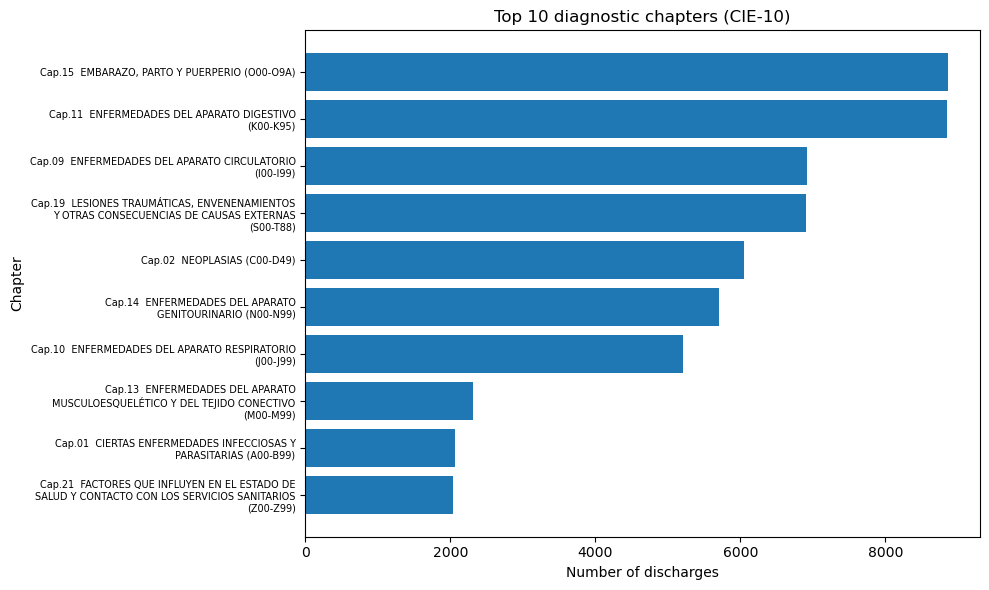

Capítulo
Cap.21  FACTORES QUE INFLUYEN EN EL ESTADO DE SALUD Y CONTACTO CON LOS SERVICIOS SANITARIOS (Z00-Z99)    2038
Cap.01  CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS (A00-B99)                                        2065
Cap.13  ENFERMEDADES DEL APARATO MUSCULOESQUELÉTICO Y DEL TEJIDO CONECTIVO (M00-M99)                     2316
Cap.10  ENFERMEDADES DEL APARATO RESPIRATORIO (J00-J99)                                                  5216
Cap.14  ENFERMEDADES DEL APARATO GENITOURINARIO (N00-N99)                                                5701
Cap.02  NEOPLASIAS (C00-D49)                                                                             6052
Cap.19  LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y OTRAS CONSECUENCIAS DE CAUSAS EXTERNAS (S00-T88)         6900
Cap.09  ENFERMEDADES DEL APARATO CIRCULATORIO (I00-I99)                                                  6925
Cap.11  ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95)                                                     8854
C

In [76]:
import textwrap

# Agrupar por capítulo y contar
top_capitulos = (
    grd_com["Capítulo"]
    .value_counts()
    .head(10)
    .sort_values()
)

# Aplicar salto de línea a etiquetas largas
labels_wrapped = [textwrap.fill(label, width=45) for label in top_capitulos.index]

# Graficar horizontal
plt.figure(figsize=(10, 6))
plt.barh(labels_wrapped, top_capitulos.values)

plt.title("Top 10 diagnostic chapters (CIE-10)")
plt.xlabel("Number of discharges")
plt.ylabel("Chapter")
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

# Tabla de apoyo
top_capitulos

Al revisar las grandes categorías de enfermedades más frecuentes, se ve que los egresos hospitalarios en Maipú no se reparten de forma pareja entre todas las causas. Destacan sobre todo embarazo, parto y puerperio, junto con enfermedades del aparato digestivo, circulatorio y lesiones traumáticas. También aparecen con bastante peso las neoplasias y las enfermedades genitourinarias. En conjunto, esto muestra que la carga hospitalaria de la comuna se concentra en un grupo relativamente acotado de grandes causas.

#### B.1.2 Top specific diagnoses

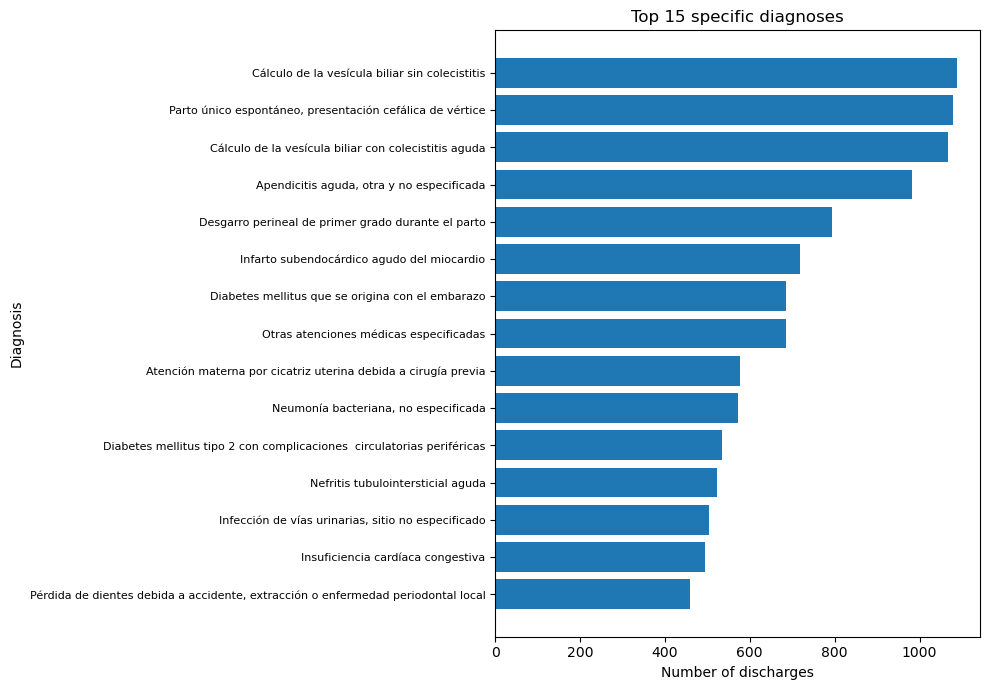

Descripción
Pérdida de dientes debida a accidente, extracción o enfermedad periodontal local     459
Insuficiencia cardíaca congestiva                                                    494
Infección de vías urinarias, sitio no especificado                                   503
Nefritis tubulointersticial aguda                                                    522
Diabetes mellitus tipo 2 con complicaciones  circulatorias periféricas               534
Neumonía bacteriana, no especificada                                                 572
Atención materna por cicatriz uterina debida a cirugía previa                        577
Otras atenciones médicas especificadas                                               685
Diabetes mellitus que se origina con el embarazo                                     686
Infarto subendocárdico agudo del miocardio                                           719
Desgarro perineal de primer grado durante el parto                                   794
Apendicit

In [79]:
# Contar diagnósticos específicos
top_diagnosticos = (
    grd_com["Descripción"]
    .value_counts()
    .head(15)
    .sort_values()
)

# Graficar barras horizontales
plt.figure(figsize=(10, 7))
plt.barh(top_diagnosticos.index, top_diagnosticos.values)

plt.title("Top 15 specific diagnoses")
plt.xlabel("Number of discharges")
plt.ylabel("Diagnosis")
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Mostrar tabla
top_diagnosticos

Al revisar los diagnósticos específicos más frecuentes, observamos que los egresos hospitalarios en Maipú siguen concentrándose en un grupo relativamente acotado de causas. Destacan principalmente los cálculos de vesícula, el parto único espontáneo, la apendicitis aguda y otras atenciones vinculadas al embarazo y al parto, lo que confirma un peso importante de las hospitalizaciones digestivas y obstétricas. A esto se suman diagnósticos como infarto subendocárdico agudo del miocardio, diabetes mellitus con complicaciones, neumonía bacteriana, nefritis tubulointersticial aguda e infecciones urinarias, lo que muestra que junto con la maternidad también tienen una presencia relevante los problemas cardiovasculares, metabólicos, respiratorios y renales.

#### B.1.3 Diagnostic chapters by nationality

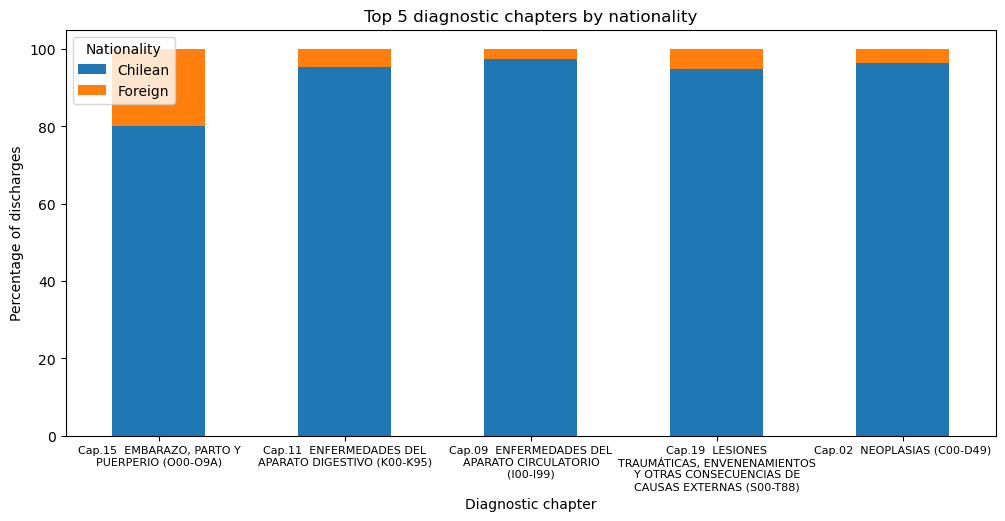

nat_group,Chilean,Foreign
Capítulo,,
"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A)",80.21,19.79
Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95),95.46,4.54
Cap.09 ENFERMEDADES DEL APARATO CIRCULATORIO (I00-I99),97.39,2.61
"Cap.19 LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y OTRAS CONSECUENCIAS DE CAUSAS EXTERNAS (S00-T88)",94.94,5.06
Cap.02 NEOPLASIAS (C00-D49),96.32,3.68


In [82]:
# Obtener top 5 capítulos
top5_capitulos = (
    grd_com["Capítulo"]
    .value_counts()
    .head(5)
    .index
)

# Filtrar top 5 capítulos
grd_top5_cap = grd_com[
    grd_com["Capítulo"].isin(top5_capitulos)
].copy()

# Contar por capítulo y nacionalidad
cap_nat = (
    grd_top5_cap
    .groupby(["Capítulo", "nat_group"])
    .size()
    .reset_index(name="n_discharges")
)

# Pasar a formato ancho
cap_nat_wide = cap_nat.pivot(
    index="Capítulo",
    columns="nat_group",
    values="n_discharges"
).fillna(0)

# Calcular proporciones
cap_nat_share = cap_nat_wide.div(
    cap_nat_wide.sum(axis=1),
    axis=0
) * 100

# Mantener orden del top 5
cap_nat_share = cap_nat_share.loc[top5_capitulos]

# Crear etiquetas con saltos de línea
wrapped_labels = [
    textwrap.fill(label, width=28)
    for label in cap_nat_share.index
]

# Graficar barras apiladas
ax = cap_nat_share.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Top 5 diagnostic chapters by nationality")
plt.xlabel("Diagnostic chapter")
plt.ylabel("Percentage of discharges")
plt.xticks(
    ticks=range(len(wrapped_labels)),
    labels=wrapped_labels,
    rotation=0,
    fontsize=8
)
plt.legend(title="Nationality")
plt.subplots_adjust(bottom=0.3)
plt.show()

# Mostrar tabla
cap_nat_share.round(2)

In [83]:
# Obtener porcentaje extranjero
pct_foreign_pop = summary_t1["pct_foreign"].iloc[0]

print(f"Pct foreign in population: {pct_foreign_pop:.2f}%")

Pct foreign in population: 6.19%


Al comparar estas categorías con el 6,19% que representa la población extranjera en Maipú, se ve que en embarazo, parto y puerperio su participación es bastante mayor a ese valor de referencia, por lo que ahí sí aparece una sobrerrepresentación relativa. En cambio, en enfermedades del aparato digestivo, circulatorio, lesiones traumáticas y neoplasias, su peso es más bajo y se mantiene por debajo de ese porcentaje. Esto muestra que la distribución por nacionalidad también cambia según la categoría general de hospitalización.

### B.2 Length of Stay & Severity

#### B.2.1 Length of stay by nationality

In [87]:
# Resumir estadía por nacionalidad
los_summary_nat = (
    grd_com
    .groupby("nat_group")["los"]
    .agg(["mean", "median"])
    .reset_index()
)

# Redondear resultados
los_summary_nat["mean"] = los_summary_nat["mean"].round(2)
los_summary_nat["median"] = los_summary_nat["median"].round(2)

# Mostrar tabla
los_summary_nat

,nat_group,mean,median
0,Chilean,7.16,3.0
1,Foreign,4.68,3.0


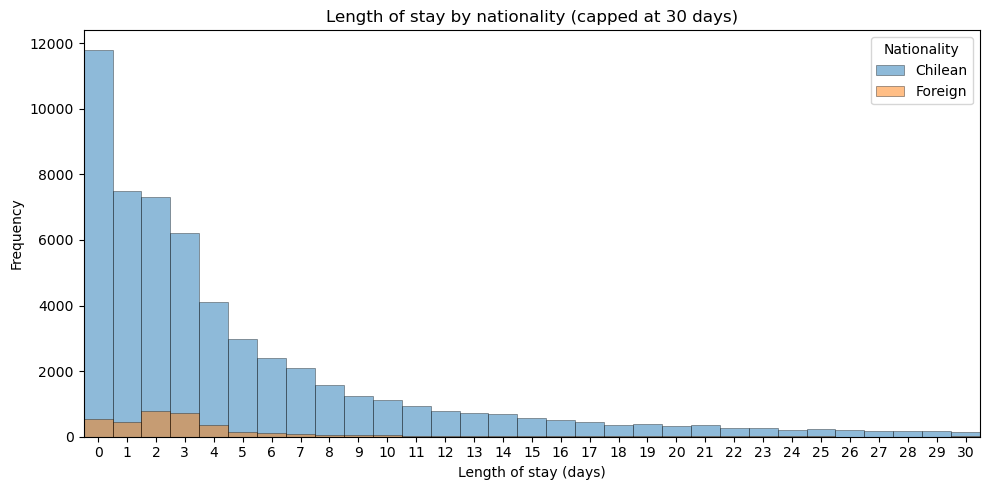

In [88]:
import matplotlib.pyplot as plt

# Acotar estadía a 30 días
grd_com_cap = grd_com[grd_com["los"] <= 30].copy()

# Definir bins centrados en enteros
bins = np.arange(-0.5, 31.5, 1)

# Graficar histogramas
plt.figure(figsize=(10, 5))

for group in ["Chilean", "Foreign"]:
    subset = grd_com_cap[grd_com_cap["nat_group"] == group]
    plt.hist(
        subset["los"],
        bins=bins,
        alpha=0.5,
        label=group,
        edgecolor="black",
        linewidth=0.5
    )

plt.title("Length of stay by nationality (capped at 30 days)")
plt.xlabel("Length of stay (days)")
plt.ylabel("Frequency")

# Poner etiquetas al centro de cada barra
plt.xticks(range(0, 31, 1))

plt.xlim(-0.5, 30.5)
plt.legend(title="Nationality")
plt.tight_layout()
plt.show()

In [89]:
# Filtrar estadías hasta 30 días
grd_com_cap = grd_com[grd_com["los"] <= 30].copy()

# Construir tabla de frecuencias igual al histograma
tabla_hist = (
    grd_com_cap
    .groupby(["los", "nat_group"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(0, 31), fill_value=0)
)

# Asegurar columnas en orden
tabla_hist = tabla_hist.reindex(columns=["Chilean", "Foreign"], fill_value=0)

# Pasar los a columna
tabla_hist = tabla_hist.reset_index()
tabla_hist.columns = ["los", "Chilean", "Foreign"]

# Mostrar tabla
tabla_hist

,los,Chilean,Foreign
0,0,11801,545
1,1,7491,452
2,2,7323,798
3,3,6210,715
4,4,4093,344
5,5,2986,151
6,6,2415,101
7,7,2086,87
8,8,1588,66
9,9,1245,50


Al comparar la estadía hospitalaria por nacionalidad, se ve que en personas chilenas el promedio es mayor, con 7,16 días frente a 4,68 en personas extranjeras. Sin embargo, la mediana es de 3 días en ambos grupos, por lo que la diferencia no parece venir de la estadía típica, sino de casos más largos que elevan el promedio en la población chilena. En el histograma también se observa que en ambos grupos la mayor parte de los egresos se concentra en pocos días de hospitalización.

#### B.2.2 Severity distribution

Convertimos la variable de severidad a formato numérico, filtramos los valores válidos y luego construimos la tabla de distribución por nacionalidad.

nat_group       Chilean  Foreign
severity_label                  
Sin gravedad    10952.0    493.0
Menor           15461.0   1667.0
Moderada        15526.0    898.0
Mayor           16993.0    624.0


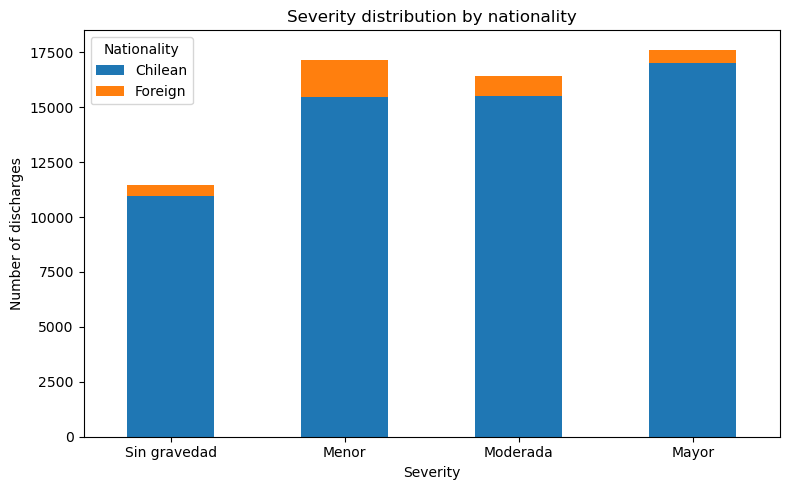

In [93]:
# Cargar etiquetas de severidad desde Excel
sev_labels = pd.read_excel(
    "TablasMaestrasBasesGRD.xlsx",
    sheet_name="Severidad GRD"
)

# Limpiar nombres de columnas
sev_labels.columns = sev_labels.columns.str.strip()

# Renombrar columnas
sev_labels = sev_labels.rename(columns={
    "Severidad": "IR_29301_SEVERIDAD",
    "Unnamed: 1": "severity_label"
})

# Limpiar etiquetas
sev_labels["severity_label"] = sev_labels["severity_label"].astype(str).str.strip()

# Convertir severidad a numérico
grd_com["IR_29301_SEVERIDAD"] = pd.to_numeric(
    grd_com["IR_29301_SEVERIDAD"],
    errors="coerce"
)

sev_labels["IR_29301_SEVERIDAD"] = pd.to_numeric(
    sev_labels["IR_29301_SEVERIDAD"],
    errors="coerce"
)

# Filtrar valores válidos
grd_sev = grd_com.merge(
    sev_labels,
    on="IR_29301_SEVERIDAD",
    how="left"
)

grd_sev = grd_sev[
    grd_sev["IR_29301_SEVERIDAD"].isin([0, 1, 2, 3])
].copy()

# Contar por severidad y nacionalidad
sev_nat = (
    grd_sev
    .groupby(["severity_label", "nat_group"])
    .size()
    .reset_index(name="n_discharges")
)

# Pasar a formato ancho
sev_nat_wide = sev_nat.pivot(
    index="severity_label",
    columns="nat_group",
    values="n_discharges"
).fillna(0)

# Reordenar severidad según tabla maestra
orden = sev_labels["severity_label"].tolist()
sev_nat_wide = sev_nat_wide.reindex(orden, fill_value=0)

# Asegurar datos numéricos
sev_nat_wide = sev_nat_wide.astype(float)

# Mostrar tabla
print(sev_nat_wide)

# Graficar barras apiladas
sev_nat_wide.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Severity distribution by nationality")
plt.xlabel("Severity")
plt.ylabel("Number of discharges")
plt.xticks(rotation=0)
plt.legend(title="Nationality")
plt.tight_layout()
plt.show()

Al revisar la severidad por nacionalidad, se ve que en la población chilena los egresos se reparten de forma más pareja entre los distintos niveles, con una presencia algo mayor en los casos clasificados como "Mayor". En la población extranjera, en cambio, la categoría "Menor" concentra una parte bastante más alta que las demás. Esto sugiere que la distribución de la severidad no sigue exactamente el mismo patrón entre ambos grupos.

#### B.2.3 Discharge type

In [96]:
# Crear indicador de fallecido
grd_com["is_dead"] = (grd_com["TIPOALTA"] == "FALLECIDO").astype(int)

# Calcular tasa de mortalidad por nacionalidad
mortality_table = (
    grd_com
    .groupby("nat_group")
    .agg(
        total_discharges=("TIPOALTA", "count"),
        deaths=("is_dead", "sum"),
        in_hospital_mortality_rate=("is_dead", "mean")
    )
    .reset_index()
)

# Expresar tasa en porcentaje
mortality_table["in_hospital_mortality_rate"] = (
    mortality_table["in_hospital_mortality_rate"] * 100
).round(2)

# Mostrar tabla
mortality_table

,nat_group,total_discharges,deaths,in_hospital_mortality_rate
0,Chilean,58932,2132,3.62
1,Foreign,3682,53,1.44


Al comparar la mortalidad intrahospitalaria por nacionalidad, se ve que en la población chilena la tasa es más alta, con 3,62%, mientras que en la población extranjera llega a 1,44%. Esto muestra que la proporción de egresos por fallecimiento no sigue el mismo patrón entre ambos grupos y que, al menos en esta base, el peso relativo de este desenlace es mayor en personas chilenas.

### B.3 Spatial View

#### B.3.1 Choropleth: hospitalization rate by comuna

Fijamos manualmente la escala de color y usamos la misma normalización para pintar la comuna y para construir la barra, de modo que el color mostrado corresponda exactamente al valor calculado de la tasa.

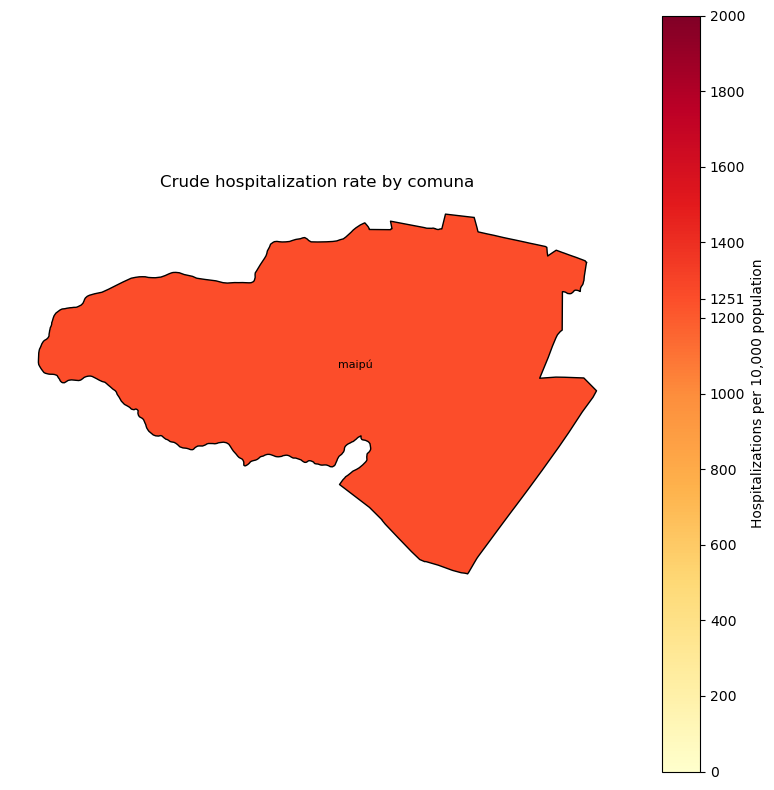

,codigo_comuna,nombre_comuna,grd_total,pop_total,hosp_rate_per_10k
0,13119,maipú,62614,500600,1250.779065


In [101]:
import geopandas as gpd
import matplotlib as mpl

# Cargar resumen de Tarea 1
summary_t1 = pd.read_csv("Comuna_Level_Summary_Table.csv", encoding="latin-1")

# Asegurar tipo de dato
summary_t1["codigo_comuna"] = summary_t1["codigo_comuna"].astype(str)

# Calcular egresos por comuna
grd_counts = (
    grd_com
    .groupby("COMUNA")
    .size()
    .reset_index(name="grd_total")
)

# Asociar código censal de Maipú
grd_counts["codigo_comuna"] = "13119"

# Unir con población
grd_rate = grd_counts.merge(
    summary_t1[["codigo_comuna", "nombre_comuna", "pop_total"]],
    on="codigo_comuna",
    how="left"
)

# Calcular tasa por 10.000 habitantes
grd_rate["hosp_rate_per_10k"] = (
    grd_rate["grd_total"] / grd_rate["pop_total"] * 10000
)

# Cargar shapefile
os.environ["SHAPE_RESTORE_SHX"] = "YES"
comunas = gpd.read_file("comunas.shp")

# Asegurar tipo de dato
comunas["cod_comuna"] = comunas["cod_comuna"].astype(str)

# Unir shapefile con tasas
mapa_grd = comunas.merge(
    grd_rate,
    left_on="cod_comuna",
    right_on="codigo_comuna",
    how="inner"
)

# Definir valor y escala fija
valor = mapa_grd["hosp_rate_per_10k"].iloc[0]
vmin = 0
vmax = 2000

# Definir colormap y normalización
cmap = plt.cm.YlOrRd
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# Obtener color exacto del valor
mapa_grd["plot_color"] = [cmap(norm(v)) for v in mapa_grd["hosp_rate_per_10k"]]

# Graficar mapa
fig, ax = plt.subplots(figsize=(8, 8))

mapa_grd.plot(
    color=mapa_grd["plot_color"],
    edgecolor="black",
    ax=ax
)

# Agregar barra de color coherente con el mapa
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Hospitalizations per 10,000 population")
cbar.set_ticks([0, 200, 400, 600, 800, 1000, 1200, round(valor, 2), 1400, 1600, 1800, 2000])

# Agregar etiqueta comunal
for x, y, label in zip(
    mapa_grd.geometry.centroid.x,
    mapa_grd.geometry.centroid.y,
    mapa_grd["nombre_comuna"]
):
    ax.text(x, y, label, fontsize=8, ha="center")

ax.set_title("Crude hospitalization rate by comuna")
ax.set_axis_off()
plt.tight_layout()
plt.show()

# Mostrar tabla de apoyo
grd_rate[["codigo_comuna", "nombre_comuna", "grd_total", "pop_total", "hosp_rate_per_10k"]]

En este caso, como el análisis se centra solo en Maipú, el mapa funciona más como una forma de ubicar espacialmente el indicador que como una herramienta de comparación entre comunas. Para esta comuna se observa una tasa de hospitalización de 1.250,78 egresos por cada 10.000 habitantes, lo que permite dimensionar mejor la magnitud del fenómeno en relación con el tamaño de su población. Más que mostrar diferencias territoriales, aquí el mapa ayuda a presentar de forma visual dónde se concentra el valor calculado.

### B.4 Comuna-Level GRD Summary Table

Normalizamos los nombres de comuna para evitar diferencias por mayúsculas, espacios o tildes y reconstruimos la tabla resumen GRD con el cruce correcto hacia la Tarea 1.

In [105]:
import unicodedata

# Normalizar texto
def normalize_text(x):
    if pd.isna(x):
        return x
    x = str(x).strip().upper()
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    return x

# Cargar tabla de la Tarea 1
summary_t1 = pd.read_csv("Comuna_Level_Summary_Table.csv", encoding="latin-1")

# Preparar llaves para el cruce
summary_t1["codigo_comuna"] = summary_t1["codigo_comuna"].astype(str)
summary_t1["nombre_comuna_norm"] = summary_t1["nombre_comuna"].apply(normalize_text)

# Normalizar nombres de comuna en GRD
grd_com["COMUNA_NORM"] = grd_com["COMUNA"].apply(normalize_text)

# Crear diccionarios de apoyo
comuna_code_map = dict(zip(summary_t1["nombre_comuna_norm"], summary_t1["codigo_comuna"]))
comuna_name_map = dict(zip(summary_t1["nombre_comuna_norm"], summary_t1["nombre_comuna"]))
pop_total_map = dict(zip(summary_t1["nombre_comuna_norm"], summary_t1["pop_total"]))

# Asegurar severidad numérica
grd_com["IR_29301_SEVERIDAD"] = pd.to_numeric(
    grd_com["IR_29301_SEVERIDAD"],
    errors="coerce"
)

# Crear indicador de fallecido
grd_com["is_dead"] = (grd_com["TIPOALTA"] == "FALLECIDO").astype(int)

# Crear función resumen
def build_grd_summary(g):
    comuna_norm = g["COMUNA_NORM"].iloc[0]
    codigo = comuna_code_map.get(comuna_norm, np.nan)
    nombre = comuna_name_map.get(comuna_norm, np.nan)
    pop_total = pop_total_map.get(comuna_norm, np.nan)

    grd_total = len(g)
    grd_chilean = (g["nat_group"] == "Chilean").sum()
    grd_foreign = (g["nat_group"] == "Foreign").sum()

    grd_pct_foreign = np.nan
    if grd_total > 0:
        grd_pct_foreign = grd_foreign / grd_total * 100

    grd_mean_los = g["los"].mean()

    grd_mean_los_chilean = g.loc[
        g["nat_group"] == "Chilean", "los"
    ].mean()

    grd_mean_los_foreign = g.loc[
        g["nat_group"] == "Foreign", "los"
    ].mean()

    grd_mean_severity = g["IR_29301_SEVERIDAD"].mean()

    grd_mortality_rate = g["is_dead"].mean() * 100

    top3 = (
        g["Capítulo"]
        .dropna()
        .value_counts()
        .head(3)
        .index
        .tolist()
    )
    grd_top3_chapters = ", ".join(top3)

    grd_rate_per_10k = np.nan
    if pd.notna(pop_total) and pop_total > 0:
        grd_rate_per_10k = grd_total / pop_total * 10000

    return pd.Series({
        "codigo_comuna": codigo,
        "nombre_comuna": nombre,
        "grd_total": grd_total,
        "grd_chilean": grd_chilean,
        "grd_foreign": grd_foreign,
        "grd_pct_foreign": grd_pct_foreign,
        "grd_mean_los": grd_mean_los,
        "grd_mean_los_chilean": grd_mean_los_chilean,
        "grd_mean_los_foreign": grd_mean_los_foreign,
        "grd_mean_severity": grd_mean_severity,
        "grd_mortality_rate": grd_mortality_rate,
        "grd_top3_chapters": grd_top3_chapters,
        "grd_rate_per_10k": grd_rate_per_10k
    })

# Construir tabla resumen
grd_summary = (
    grd_com.groupby("COMUNA_NORM")
    .apply(build_grd_summary)
    .reset_index(drop=True)
)

# Redondear resultados
grd_summary["grd_pct_foreign"] = grd_summary["grd_pct_foreign"].round(2)
grd_summary["grd_mean_los"] = grd_summary["grd_mean_los"].round(2)
grd_summary["grd_mean_los_chilean"] = grd_summary["grd_mean_los_chilean"].round(2)
grd_summary["grd_mean_los_foreign"] = grd_summary["grd_mean_los_foreign"].round(2)
grd_summary["grd_mean_severity"] = grd_summary["grd_mean_severity"].round(2)
grd_summary["grd_mortality_rate"] = grd_summary["grd_mortality_rate"].round(2)
grd_summary["grd_rate_per_10k"] = grd_summary["grd_rate_per_10k"].round(2)

# Definir descripciones
descriptions_grd = {
    "codigo_comuna": "Numeric comuna code",
    "nombre_comuna": "Comuna name",
    "grd_total": "Total discharges (2022-2024)",
    "grd_chilean": "Discharges, Chilean nationals",
    "grd_foreign": "Discharges, foreign nationals",
    "grd_pct_foreign": "% of discharges by foreign nationals",
    "grd_mean_los": "Mean length of stay (days)",
    "grd_mean_los_chilean": "Mean length of stay, Chilean",
    "grd_mean_los_foreign": "Mean length of stay, foreign",
    "grd_mean_severity": "Mean severity score",
    "grd_mortality_rate": "In-hospital mortality rate (% FALLECIDO)",
    "grd_top3_chapters": "Top 3 ICD-10 chapters (comma-separated)",
    "grd_rate_per_10k": "Crude hospitalization rate per 10,000 population"
}

# Crear tabla vertical
grd_summary_display = grd_summary.iloc[0].reset_index()
grd_summary_display.columns = ["Column", "Results"]

# Agregar descripciones
grd_summary_display["Description"] = grd_summary_display["Column"].map(descriptions_grd)

# Reordenar columnas
grd_summary_display = grd_summary_display[["Column", "Description", "Results"]]

# Mostrar tabla
grd_summary_display

,Column,Description,Results
0,codigo_comuna,Numeric comuna code,13119
1,nombre_comuna,Comuna name,maipú
2,grd_total,Total discharges (2022-2024),62614
3,grd_chilean,"Discharges, Chilean nationals",58932
4,grd_foreign,"Discharges, foreign nationals",3682
5,grd_pct_foreign,% of discharges by foreign nationals,5.88
6,grd_mean_los,Mean length of stay (days),7.02
7,grd_mean_los_chilean,"Mean length of stay, Chilean",7.16
8,grd_mean_los_foreign,"Mean length of stay, foreign",4.68
9,grd_mean_severity,Mean severity score,1.64
